In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense  #These are the building blocks of CNN.
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dropout   #Used to reduce overfitting

import numpy as np
import matplotlib.pyplot as plt

Sequential used to NN layer by layer,
Load is used to load a saved model, Conv2D is used to extract features of image like edges, corners,  shape, etc  , MAXPooling Reduces image size

In [ ]:
from tensorflow.keras.datasets import cifar10     #cifar10

(x_train,y_train),(x_test,y_test) = cifar10.load_data()

print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [ ]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

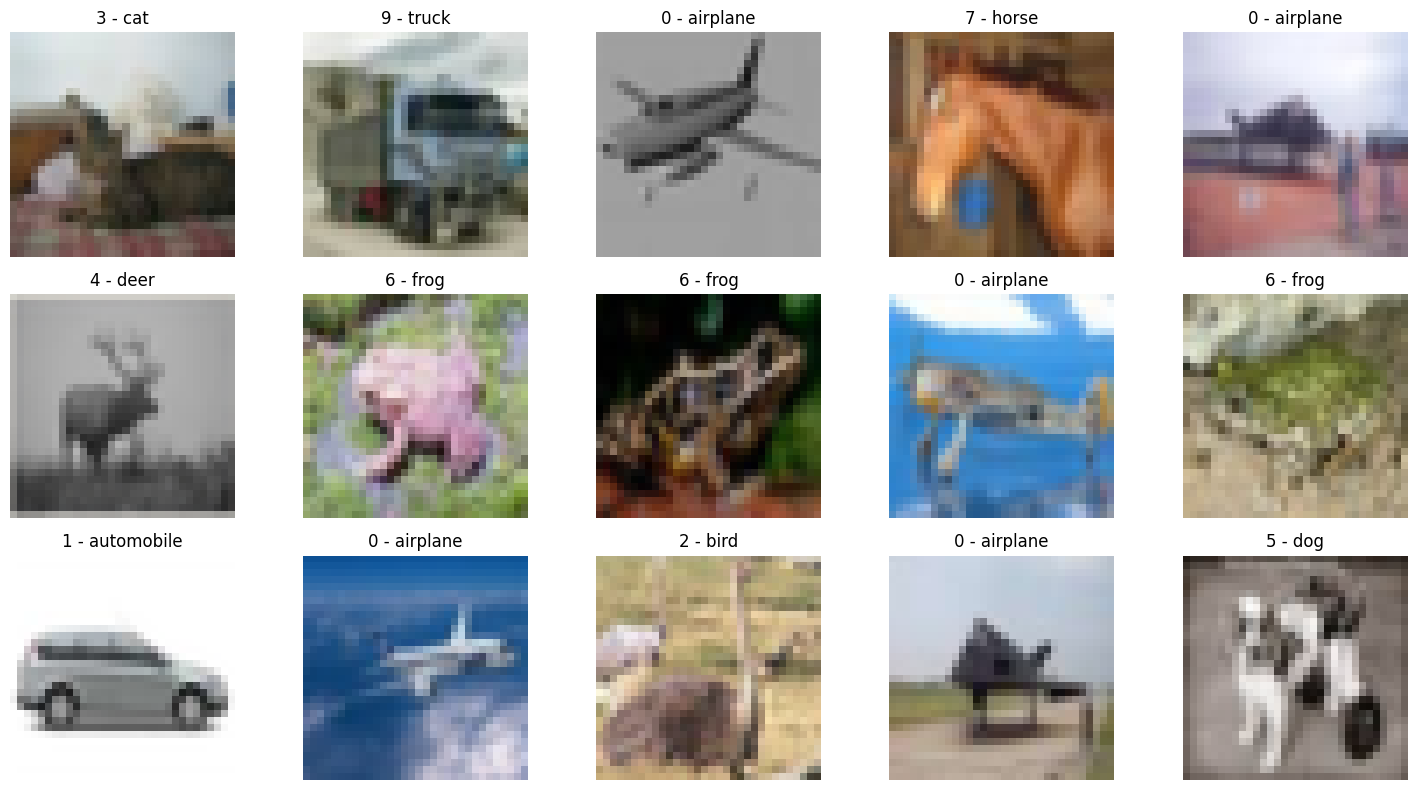

In [ ]:
plt.figure(figsize=(15,8))  #width 15 and height = 8 inches

for i in range(15):

    idx = np.random.randint(0, len(x_train))    # 15 times pick random number b\w 0 and 49999

    label = y_train[idx][0]    #gets the lebel of selected image
    name = class_names[label]  #gets the names

    plt.subplot(3,5,i+1)    #creates a grid of subplots in 3 rows 5 cols
    plt.imshow(x_train[idx])   #display the selected image

    plt.title(f"{label} - {name}")

    plt.axis("off")

plt.tight_layout()    #adjust space between them automatically
plt.show()            #Display everything

In [ ]:
#plt.title(f"Label: {label}\n{name}")

In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
#CELL 6: Build CNN Model

model = models.Sequential()     #creates an empty model

#First Convolution Layer
model.add(layers.Conv2D(32,(3,3),                  #Conv2D is used to extract features having filter 32, of size\kernal 3*3
                        activation='relu',
                        input_shape=(32,32,3)))    #input image size 32*32 and 3 rgb channels

#First Pooling Layer
model.add(layers.MaxPooling2D((2,2)))     #reduces size having size 2*2

#Second Convolution Layer
model.add(layers.Conv2D(64,(3,3),                 #by using double filters bcoz more filter more learning power
                        activation='relu'))

#Second Pooling Layer
model.add(layers.MaxPooling2D((2,2)))

#Dropout Layer
model.add(layers.Dropout(0.25))             #dropout is used to reduce overfitting becoz it randomly turns off 25% of neurons

#Third Convolution Layer
model.add(layers.Conv2D(64,(3,3),
                        activation='relu'))

#Flatten Layer
model.add(layers.Flatten())

#Dense Hidden Layer
model.add(layers.Dense(128,activation='relu'))     #combining all the features

#Dropout Layer
model.add(layers.Dropout(0.5))    #randomly turns offing 50% of neurons

#Output Layer
model.add(layers.Dense(10,
                       activation='softmax'))  #there are 10 classes so dense (10) creates 10 output neurnon , which is multiclass classification

In [ ]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,810 (737.54 KB)

 Trainable params: 188,810 (737.54 KB)

 Non-trainable params: 0 (0.00 B)

30* 30 = 3* 3 = using n-m+1

MODEL COMPILATION

In [ ]:
learning_rate = 0.0001

model.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


TRAINING DATA

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=25,
    validation_split=0.2
)

Epoch 1/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.2609 - loss: 1.9819 - val_accuracy: 0.3992 - val_loss: 1.6777
Epoch 2/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3877 - loss: 1.6710 - val_accuracy: 0.4456 - val_loss: 1.5381
Epoch 3/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.4332 - loss: 1.5515 - val_accuracy: 0.4897 - val_loss: 1.4285
Epoch 4/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4625 - loss: 1.4831 - val_accuracy: 0.5067 - val_loss: 1.3817
Epoch 5/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.4846 - loss: 1.4331 - val_accuracy: 0.5298 - val_loss: 1.3300
Epoch 6/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5039 - loss: 1.3835 - val_accuracy: 0.5429 - val_loss: 1.3005
Epoch 7/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5170 - loss: 1.3512 - val_accuracy: 0.5418 - val_loss: 1.2875
Epoch 8/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5318 - loss: 1.3187 -

CALCULATING TEST DATA ACCURACY

In [ ]:
test_loss,test_accuracy = model.evaluate(
    x_test,
    y_test
)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6686 - loss: 0.9434
Test Loss : 0.9434
Test Accuracy : 66.86%


PLOTTING ACCURACY GRAPH

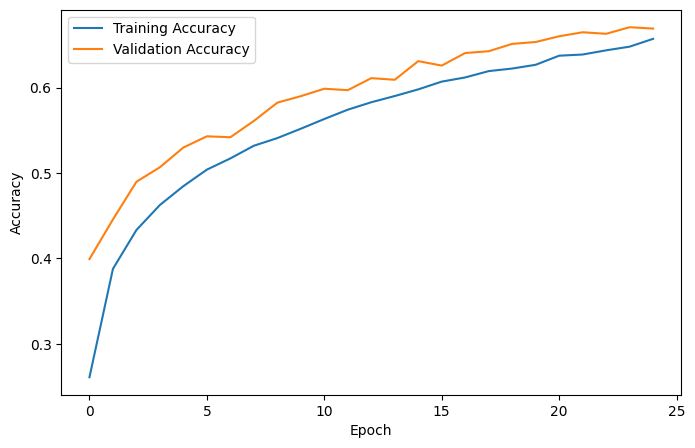

In [ ]:
# CELL 10: Plot Accuarcy Graph

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()                 #Legend is used to define lines i.e to make defining box
plt.show()

PLOTTING LOSS GRAPH

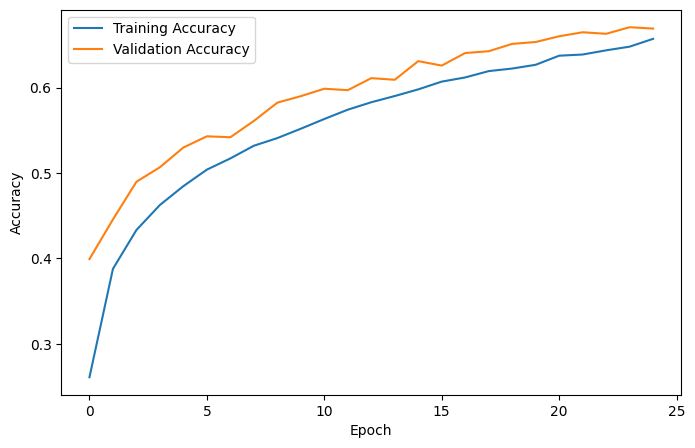

In [ ]:
# CELL 10: Plot Accuarcy Graph

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

SAVE THE MODEL

In [ ]:
model.save("cnn_cifar10.keras")

print("Model Saved Successfully")

Model Saved Successfully


LOAD THE SAVED MODEL

In [ ]:
loaded_model = load_model("cnn_cifar10.keras")

print("Model Loaded Successfully")

Model Loaded Successfully


CHOOSE A RANDOM IMAGE NUMBER FROM THE TEST DATA SET

In [ ]:
random_index = np.random.randint(0,len(x_test))    #SUPPOSE 5234

sample_image = x_test[random_index]   #Stored in sample

actual_label = y_test[random_index][0]  #write actual label of it

In [ ]:
# Select one image
sample_image = x_test[random_index]

# Add batch dimension for CNN prediction
input_image = np.expand_dims(sample_image, axis=0)

print("Original Shape :", sample_image.shape)
print("New Shape :", input_image.shape)

Original Shape : (32, 32, 3)
New Shape : (1, 32, 32, 3)


In [ ]:
prediction = loaded_model.predict(input_image, verbose=0)    #sends the selected image to the CNN trained model and returns proba for 10 classes , verbose = 0 means don't show progress msg

predicted_label = np.argmax(prediction)   #find the position of largest probability

print("Predicted Label :", predicted_label)

Predicted Label : 9


In [ ]:
#prediction = loaded_model.predict(                 #The trained CNN receives the image and returns proba for 10 classes
 #   input_image,
 #   verbose=0
#)

#predicted_label = np.argmax(prediction)       #find the position of largest probability

confidence = np.max(prediction)*100   #returns the highest probability in percent form

In [ ]:
print("Actual Label :",actual_label)

print("Predicted Label :",predicted_label)

print(
    f"Prediction Confidence : {confidence:.2f}%"
)

Actual Label : 9
Predicted Label : 9
Prediction Confidence : 92.10%


In [ ]:
print("\nProbabilities")

for i,prob in enumerate(prediction[0]):
    print(
        f"Class {i}: {prob*100:.2f}%"
    )


Probabilities
Class 0: 1.32%
Class 1: 0.53%
Class 2: 0.24%
Class 3: 0.62%
Class 4: 0.19%
Class 5: 0.48%
Class 6: 0.03%
Class 7: 2.95%
Class 8: 1.53%
Class 9: 92.10%


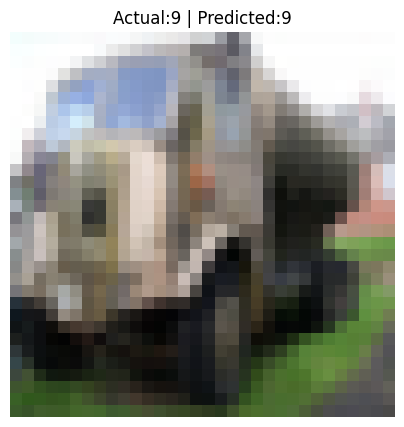

In [ ]:
plt.figure(figsize=(5,5))

plt.imshow(sample_image)

plt.title(
    f"Actual:{actual_label} | Predicted:{predicted_label}"
)

plt.axis("off")

plt.show()